In [3]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [4]:
df_org=pd.read_csv('Telco_churn_dataset.csv')

In [5]:
df_org.sample(4)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2664,6242-SGYTS,Male,0,Yes,Yes,62,Yes,Yes,Fiber optic,Yes,...,No,No,Yes,No,One year,Yes,Credit card (automatic),94.95,5791.85,No
479,6227-HWPWX,Female,0,No,Yes,15,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,No,Bank transfer (automatic),69.00,994.8,Yes
6975,1904-WAJAA,Female,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,No,No,No,Two year,No,Electronic check,64.35,1558.65,No
6830,7815-PDTHL,Male,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Mailed check,20.20,684.4,No


In [6]:
X = df_org.drop('Churn', axis=1)
Y = df_org['Churn']

In [7]:
Y = Y.map({
    'Yes':1,
    'No':0
})
Y = Y.astype(int)

In [8]:
Y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int32

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (FunctionTransformer)
from sklearn.tree import DecisionTreeClassifier

# Evaluation Metrics
from sklearn.metrics import (

    accuracy_score,

    classification_report,

    confusion_matrix
)




num_columns = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

multi_columns = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

binary_columns = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
]


def basic_cleaning(df1):

    df1 = df1.copy()

    # Remove customerID
    df1 = df1.drop('customerID', axis=1)

    # Convert TotalCharges
    df1['TotalCharges'] = pd.to_numeric(df1['TotalCharges'],errors='coerce')

    # Fill missing values
    df1['TotalCharges'] = df1['TotalCharges'].fillna(df1['TotalCharges'].median())

    # Binary mapping
    binary_map = {
        'Yes':1,
        'No':0,
        'Female':0,
        'Male':1
    }

    for col in binary_columns:
        df1[col] = df1[col].map(binary_map)

    return df1

In [19]:
preprocessor = ColumnTransformer([('num', StandardScaler(), num_columns ),
                                  ('cat', OneHotEncoder(drop='first'),multi_columns)
                                  ],remainder='passthrough')

In [14]:
depths = []
accuracies = []

# Try different max_depth values
for depth in range(1, 21):





    pipeline=Pipeline([
    ('cleaning',FunctionTransformer(basic_cleaning)),
    ('preprocessing',preprocessor),
    ('model', DecisionTreeClassifier(
            max_depth=depth,
            random_state=42
        ))])



    # Train model
    pipeline.fit(X_train, y_train)

    # Prediction
    y_pred = pipeline.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    depths.append(depth)
    accuracies.append(acc)

    print(f"Max Depth: {depth}  Accuracy: {acc:.4f}")

Max Depth: 1  Accuracy: 0.7353
Max Depth: 2  Accuracy: 0.8020
Max Depth: 3  Accuracy: 0.8020
Max Depth: 4  Accuracy: 0.8027
Max Depth: 5  Accuracy: 0.8062
Max Depth: 6  Accuracy: 0.7977
Max Depth: 7  Accuracy: 0.7913
Max Depth: 8  Accuracy: 0.7892
Max Depth: 9  Accuracy: 0.7779
Max Depth: 10  Accuracy: 0.7651
Max Depth: 11  Accuracy: 0.7566
Max Depth: 12  Accuracy: 0.7495
Max Depth: 13  Accuracy: 0.7402
Max Depth: 14  Accuracy: 0.7289
Max Depth: 15  Accuracy: 0.7225
Max Depth: 16  Accuracy: 0.7161
Max Depth: 17  Accuracy: 0.7204
Max Depth: 18  Accuracy: 0.7048
Max Depth: 19  Accuracy: 0.7246
Max Depth: 20  Accuracy: 0.7140


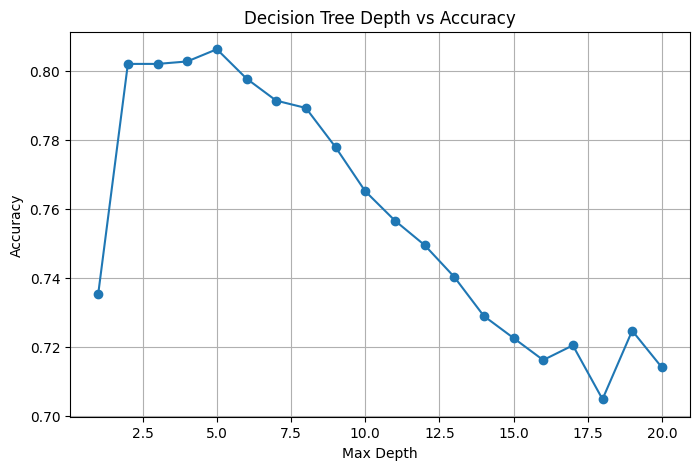

In [16]:
import matplotlib.pyplot as plt
# Draw graph
plt.figure(figsize=(8,5))

plt.plot(depths, accuracies, marker='o')

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Depth vs Accuracy")

plt.grid(True)

plt.show()

In [17]:

pipeline =Pipeline([
    ('cleaning',FunctionTransformer(basic_cleaning)),
    ('preprocessing',preprocessor),
    ('model', DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        ))])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)

print("Final Accuracy:", acc)

Final Accuracy: 0.8062455642299503


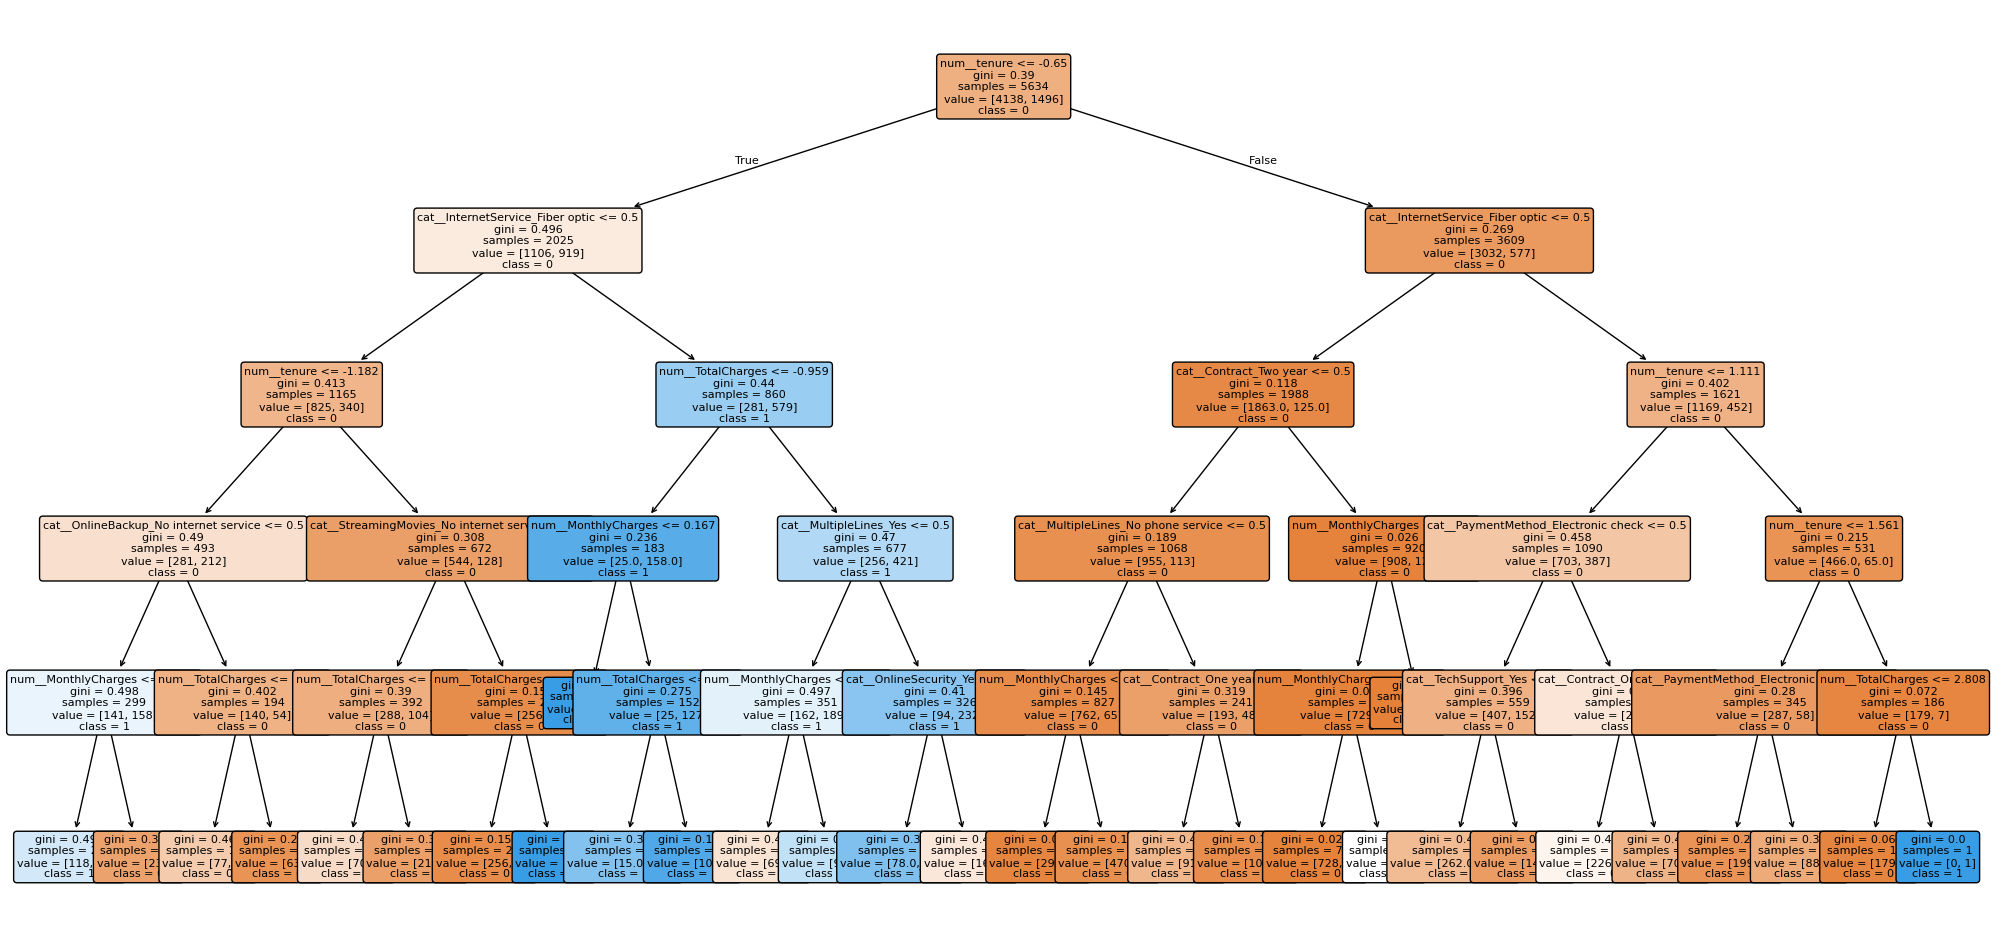

In [21]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Get trained tree model
tree_model = pipeline.named_steps['model']

# Get feature names after preprocessing
feature_names = pipeline.named_steps[
    'preprocessing'
].get_feature_names_out()

# Get class names
class_names = [str(i) for i in pipeline.classes_]

# Plot tree
plt.figure(figsize=(25,12))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()